In [ ]:
from google.colab import drive
import os

# mount your google drive
drive.mount('/content/drive')

# create a folder in drive to hold everything
drive_folder = '/content/drive/MyDrive/Medical_AI_Project'
os.makedirs(drive_folder, exist_ok=True)

print(f"Drive connected! Files will be saved to: {drive_folder}")

Mounted at /content/drive
Drive connected! Files will be saved to: /content/drive/MyDrive/Medical_AI_Project


In [2]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes datasets

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-ktekoaqk/unsloth_e20ce1ae7ea942f29c99caab83b9b572
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-ktekoaqk/unsloth_e20ce1ae7ea942f29c99caab83b9b572
  Resolved https://github.com/unslothai/unsloth.git to commit dfba4cc5cae7c95871c0faced86b9cefd5808b28
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 18.0 MB/s eta 0:00:00

In [3]:
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
import torch

import matplotlib.pyplot as plt
import seaborn as sns

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
MAX_SEQ_LENGTH = 1024

In [ ]:
# Load the base model in 4-bit quantization which Shrinks it
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Phi-3-mini-4k-instruct",
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.5.9: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/194 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.34k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

In [6]:
# Attach the LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

Unsloth 2026.5.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [7]:
prompt_template = "<|user|>\n{input}<|end|>\n<|assistant|>\n{output}<|end|>"

def format_dataset(examples):
    texts = [prompt_template.format(input=i, output=o) for i, o in zip(examples["input"], examples["output"])]
    return { "text" : texts }

# Load our 10,000 sampled rows
dataset = load_dataset("lavita/ChatDoctor-HealthCareMagic-100k", split="train")
dataset = dataset.shuffle(seed=42).select(range(10000)).map(format_dataset, batched = True)

README.md:   0%|          | 0.00/542 [00:00<?, ?B/s]

data/train-00000-of-00001-5e7cb295b9cff0(…):   0%|          | 0.00/70.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/112165 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 10,
        output_dir = "outputs",
        optim = "adamw_8bit",
        seed = 3407,
    ),
)

print("Starting training! (Takes ~1 hour)")
trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/10000 [00:00<?, ? examples/s]

Starting training! (Takes ~1 hour)


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 1 | Total steps = 1,250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,884,416 of 3,850,963,968 (0.78% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,2.674755
20,2.518377
30,2.515466
40,2.353160
50,2.401581
60,2.396495
70,2.374764
80,2.360910
90,2.313540
100,2.354441


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-500.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1000/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-1000.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1250/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-1250.


TrainOutput(global_step=1250, training_loss=2.232165643310547, metrics={'train_runtime': 3579.9078, 'train_samples_per_second': 2.793, 'train_steps_per_second': 0.349, 'total_flos': 6.979158571732992e+16, 'train_loss': 2.232165643310547, 'epoch': 1.0})

In [ ]:
# save out trained lora adapters
model.save_pretrained("phi3_doctor_lora")
tokenizer.save_pretrained("phi3_doctor_lora")
print("Saved!")

Unsloth: Restored added_tokens_decoder metadata in phi3_doctor_lora/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in phi3_doctor_lora.


Saved!


In [10]:
# zip and upload to drive

!zip -r my_medical_adapters.zip phi3_doctor_lora/

!cp my_medical_adapters.zip /content/drive/MyDrive/Medical_AI_Project/

  adding: phi3_doctor_lora/ (stored 0%)
  adding: phi3_doctor_lora/README.md (deflated 65%)
  adding: phi3_doctor_lora/tokenizer.json (deflated 85%)
  adding: phi3_doctor_lora/chat_template.jinja (deflated 60%)
  adding: phi3_doctor_lora/tokenizer.model (deflated 55%)
  adding: phi3_doctor_lora/adapter_model.safetensors (deflated 7%)
  adding: phi3_doctor_lora/tokenizer_config.json (deflated 86%)
  adding: phi3_doctor_lora/adapter_config.json (deflated 59%)


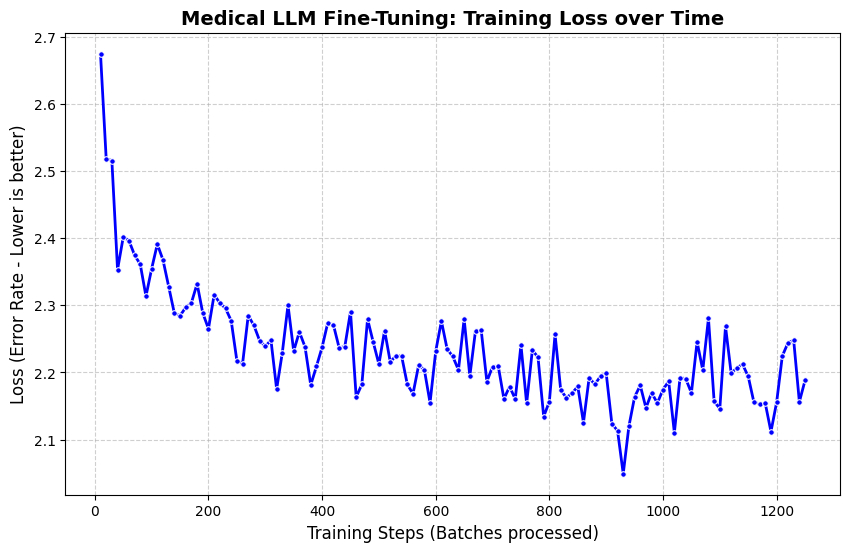

In [11]:
# The trainer saves all the stats in its state history
log_history = trainer.state.log_history

# Create empty lists to store our data
steps = []
training_loss = []

# Loop through the logs and grab the loss at each step
for entry in log_history:
    if "loss" in entry and "step" in entry:
        steps.append(entry["step"])
        training_loss.append(entry["loss"])


# plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=steps, y=training_loss, color='blue', linewidth=2, marker='o', markersize=4)
plt.title('Medical LLM Fine-Tuning: Training Loss over Time', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps (Batches processed)', fontsize=12)
plt.ylabel('Loss (Error Rate - Lower is better)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("medical_training_loss.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# upload the plot to drive

!cp medical_training_loss.png /content/drive/MyDrive/Medical_AI_Project/

In [ ]:
# merge the lora adapters with the base model
model.save_pretrained_merged("phi3_doctor_merged", tokenizer, save_method="merged_16bit")


# zip merged model and upload to drive
!zip -r phi3_doctor_merged.zip phi3_doctor_merged/
!cp phi3_doctor_merged.zip /content/drive/MyDrive/Medical_AI_Project/